In [36]:
import pandas as pd
import numpy as np
import os
from catboost import CatBoostRegressor

df = pd.read_csv("../data/raw/kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (21613, 21)

Columns:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [6]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [8]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21613, 20)
y shape: (21613,)


In [9]:
df["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

<Axes: >

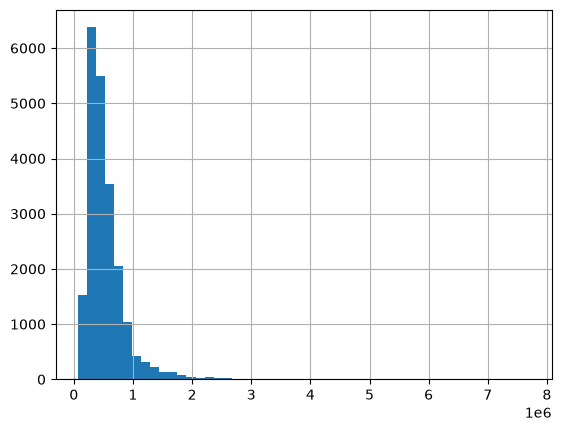

In [10]:
df["price"].hist(bins=50)

In [11]:
df[["id", "date", "zipcode"]].head(10)

,id,date,zipcode
0,7129300520,20141013T000000,98178
1,6414100192,20141209T000000,98125
2,5631500400,20150225T000000,98028
3,2487200875,20141209T000000,98136
4,1954400510,20150218T000000,98074
5,7237550310,20140512T000000,98053
6,1321400060,20140627T000000,98003
7,2008000270,20150115T000000,98198
8,2414600126,20150415T000000,98146
9,3793500160,20150312T000000,98038


In [12]:
df["date"].value_counts().head(10)

date
20140623T000000    142
20140626T000000    131
20140625T000000    131
20140708T000000    127
20150427T000000    126
20150325T000000    123
20150428T000000    121
20140709T000000    121
20150414T000000    121
20150422T000000    121
Name: count, dtype: int64

In [13]:
df[["bedrooms", "bathrooms", "floors", "waterfront", "view", "condition", "grade"]].describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms,21613.0,3.370842,0.930062,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
floors,21613.0,1.494309,0.539989,1.0,1.00,1.50,2.0,3.5
waterfront,21613.0,0.007542,0.086517,0.0,0.00,0.00,0.0,1.0
view,21613.0,0.234303,0.766318,0.0,0.00,0.00,0.0,4.0
condition,21613.0,3.409430,0.650743,1.0,3.00,3.00,4.0,5.0
grade,21613.0,7.656873,1.175459,1.0,7.00,7.00,8.0,13.0


In [14]:
df[df["bedrooms"] >= 10][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "grade"]
].sort_values("bedrooms", ascending=False)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade
15870,640000.0,33,1.75,1620,6000,7
8757,520000.0,11,3.00,3000,4960,7
13314,1148000.0,10,5.25,4590,10920,9
15161,650000.0,10,2.00,3610,11914,7
19254,660000.0,10,3.00,2920,3745,7


In [15]:
clean_df = df[df["bedrooms"] != 33].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))

Original rows: 21613
Cleaned rows: 21612


In [16]:
data = clean_df.copy()

# Convert date
data["date"] = pd.to_datetime(data["date"])

# Extract useful date features
data["sale_year"] = data["date"].dt.year
data["sale_month"] = data["date"].dt.month

# Remove ID and raw date
data = data.drop(columns=["id", "date"])

print(data.shape)
print(data.columns.tolist())

(21612, 21)
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']


In [17]:
# Feature engineering

data["house_age"] = data["sale_year"] - data["yr_built"]

data["years_since_renovation"] = np.where(
    (data["yr_renovated"] == 0) |
    (data["yr_renovated"] > data["sale_year"]),
    0,
    data["sale_year"] - data["yr_renovated"]
)

data["total_sqft"] = data["sqft_above"] + data["sqft_basement"]

data["living_to_lot_ratio"] = (
    data["sqft_living"] / data["sqft_lot"].replace(0, np.nan)
)

data["living_sqft_per_bedroom"] = (
    data["sqft_living"] / data["bedrooms"].replace(0, np.nan)
)

data["bathrooms_per_bedroom"] = (
    data["bathrooms"] / data["bedrooms"].replace(0, np.nan)
)

data = data.replace([np.inf, -np.inf], np.nan)

print("Features:", data.drop(columns=["price"]).shape[1])

Features: 26


In [18]:
from sklearn.model_selection import train_test_split

data["living_sqft_per_bedroom"] = (
    data["living_sqft_per_bedroom"]
    .fillna(data["living_sqft_per_bedroom"].median())
)

data["bathrooms_per_bedroom"] = (
    data["bathrooms_per_bedroom"]
    .fillna(data["bathrooms_per_bedroom"].median())
)

X = data.drop(columns=["price"])
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Features:", X.shape[1])
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Features: 26
Training samples: 17289
Testing samples: 4323


In [19]:
# Baseline Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $125,890.46
RMSE: $210,245.75
R²:   0.7055


In [20]:
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

MAE:  $72,707.68
RMSE: $145,823.87
R²:   0.8583


In [28]:
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    cat_features=["zipcode"]
)

grid = {
    "iterations": [800, 1200],
    "depth": [7, 9],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5]
}

catboost_model.grid_search(
    grid,
    X=X_train,
    y=y_train,
)

0:	learn: 631055.2757574	test: 637927.8797784	best: 637927.8797784 (0)	total: 73.3ms	remaining: 58.6s
100:	learn: 137901.7657585	test: 146600.9490846	best: 146600.9490846 (100)	total: 5.83s	remaining: 40.4s
200:	learn: 111800.8104648	test: 127329.1484996	best: 127329.1484996 (200)	total: 10.2s	remaining: 30.4s
300:	learn: 103540.2618179	test: 121872.8184865	best: 121872.8184865 (300)	total: 14.9s	remaining: 24.6s
400:	learn: 96211.9823175	test: 117881.1097774	best: 117881.1097774 (400)	total: 19.1s	remaining: 19s
500:	learn: 90547.0077869	test: 115186.2027605	best: 115186.2027605 (500)	total: 24.1s	remaining: 14.4s
600:	learn: 85965.9043666	test: 113487.1964737	best: 113487.1964737 (600)	total: 29.4s	remaining: 9.75s
700:	learn: 82218.9675182	test: 112381.1294513	best: 112372.8297813 (699)	total: 35s	remaining: 4.94s
799:	learn: 79184.8313138	test: 111605.6570736	best: 111605.6570736 (799)	total: 39.9s	remaining: 0us

bestTest = 111605.6571
bestIteration = 799

0:	loss: 111605.6570736	

{'params': {'depth': 7,
  'learning_rate': 0.05,
  'l2_leaf_reg': 5,
  'iterations': 1200},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               4

In [32]:
catboost_pred = catboost_model.predict(X_test)

catboost_mae = mean_absolute_error(y_test, catboost_pred)
catboost_rmse = np.sqrt(mean_squared_error(y_test, catboost_pred))
catboost_r2 = r2_score(y_test, catboost_pred)

print(f"MAE:  ${catboost_mae:,.2f}")
print(f"RMSE: ${catboost_rmse:,.2f}")
print(f"R²:   {catboost_r2:.4f}")

MAE:  $63,020.69
RMSE: $113,638.49
R²:   0.9140


In [24]:
feature_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

lat              22.749048
long             13.451942
grade            10.871798
zipcode           9.534408
total_sqft        8.267802
sqft_living       8.109983
sqft_above        4.014117
sqft_living15     3.751320
view              3.600363
waterfront        3.488343
house_age         1.728401
yr_built          1.463880
sqft_lot          1.292531
sqft_lot15        0.996954
bathrooms         0.921330
dtype: float64

In [37]:
os.makedirs("../models", exist_ok=True)

catboost_model.save_model("../models/house_price_model.cbm")

print("Model saved successfully.")

Model saved successfully.


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "CatBoost",
    ],
    "MAE": [
        125890.46,
        72707.68,
        63020.69,
    ],
    "RMSE": [
        210245.75,
        145823.87,
        113638.49,
    ],
    "R2": [
        0.7055,
        0.8583,
        0.9140,
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,125890.46,210245.75,0.7055
1,Random Forest,72707.68,145823.87,0.8583
2,CatBoost,63020.69,113638.49,0.9140
